<div align="center">

## Gini KNN: Application on Energy Efficiency

## [S. Mussard](https://sites.google.com/view/cv-stphane-mussard/accueil "Homepage")

</div>

Tsanas, A. & Xifara, A. (2012). Energy Efficiency [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C51307.

In [1]:
from sklearn.datasets import load_iris, load_wine, load_digits, load_breast_cancer, fetch_openml
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report 
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

In [2]:
from Knn_Gini import GiniDistance

In [3]:
# Data
df = pd.read_excel("Concrete_Data.xls")
df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')

In [4]:
X = df[['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)']]
y = df['Concrete compressive strength(MPa, megapascals) ']
X = np.array(X)
y = np.array(y)

### How to use Sklearn's KNN with Gini prametric ?

In [5]:
# Split data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


(824, 8) (206, 8)


In [17]:
# Prediction: Gini vs. Minkowski
RMSE_gini = []
RMSE_minkowski = []
nu_values = []
for nu in np.arange(1.1, 4, 0.1):
    model = GiniDistance(X_train, gini_param=nu)
    train_distances_gini = model.compute_distances(X_train)
    test_distances_gini = model.compute_distances(X_test)
    knn_Gini = KNeighborsRegressor(n_neighbors=3, metric='precomputed')
    y_pred = knn_Gini.fit(train_distances_gini, y_train).predict(test_distances_gini)
    RMSE_gini.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    knn = KNeighborsRegressor(n_neighbors=3, p=nu, metric='minkowski')
    y_pred = knn.fit(X_train, y_train).predict(X_test)
    RMSE_minkowski.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    nu_values.append(nu)

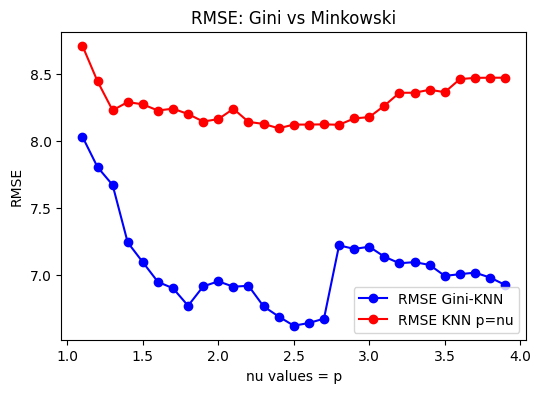

In [7]:
# Plot
plt.figure(figsize=(6, 4))
plt.plot(nu_values, RMSE_gini, marker='o', linestyle='-', color='b', label = 'RMSE Gini-KNN')
plt.plot(nu_values, RMSE_minkowski , marker='o', color='r', label='RMSE KNN p=nu', zorder=5) 
#plt.scatter(1, MSE, color='r', label='RMSE KNN p=1', zorder=5) 
#plt.scatter(1, MSE_2, label='RMSE KNN p=2', zorder=5) 
plt.title('RMSE: Gini vs Minkowski')
plt.xlabel('nu values = p')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [21]:
import statsmodels.api as sm
x_train = sm.add_constant(X_train)
x_test = sm.add_constant(X_test)
model_ols = sm.OLS(y_train,x_train)
y_pred_ols = model_ols.fit().predict(x_test)
RMSE_ols = np.sqrt(mean_squared_error(y_pred_ols,y_test))


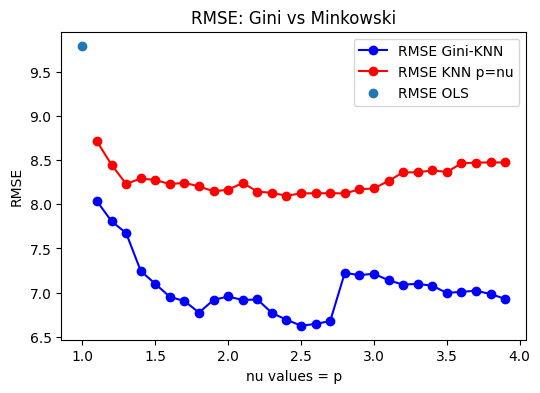

In [22]:
# Plot
plt.figure(figsize=(6, 4))
plt.plot(nu_values, RMSE_gini, marker='o', linestyle='-', color='b', label = 'RMSE Gini-KNN')
plt.plot(nu_values, RMSE_minkowski , marker='o', color='r', label='RMSE KNN p=nu', zorder=5) 
plt.scatter(1, RMSE_ols, label='RMSE OLS', zorder=5) 
plt.title('RMSE: Gini vs Minkowski')
plt.xlabel('nu values = p')
plt.ylabel('RMSE')
plt.legend()
plt.show()